In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cargar
df_dayActivity = pd.read_csv('01 dailyActivity_merged.csv')
print(df_dayActivity['Id'].nunique())
print()
print(df_dayActivity['Id'].unique())

33

[1503960366 1624580081 1644430081 1844505072 1927972279 2022484408
 2026352035 2320127002 2347167796 2873212765 3372868164 3977333714
 4020332650 4057192912 4319703577 4388161847 4445114986 4558609924
 4702921684 5553957443 5577150313 6117666160 6290855005 6775888955
 6962181067 7007744171 7086361926 8053475328 8253242879 8378563200
 8583815059 8792009665 8877689391]


C:\Users\andre\AppData\Local\Temp\ipykernel_31820\3812075344.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_dayActivity, x='DayOfWeek', order=week_order, palette='winter')


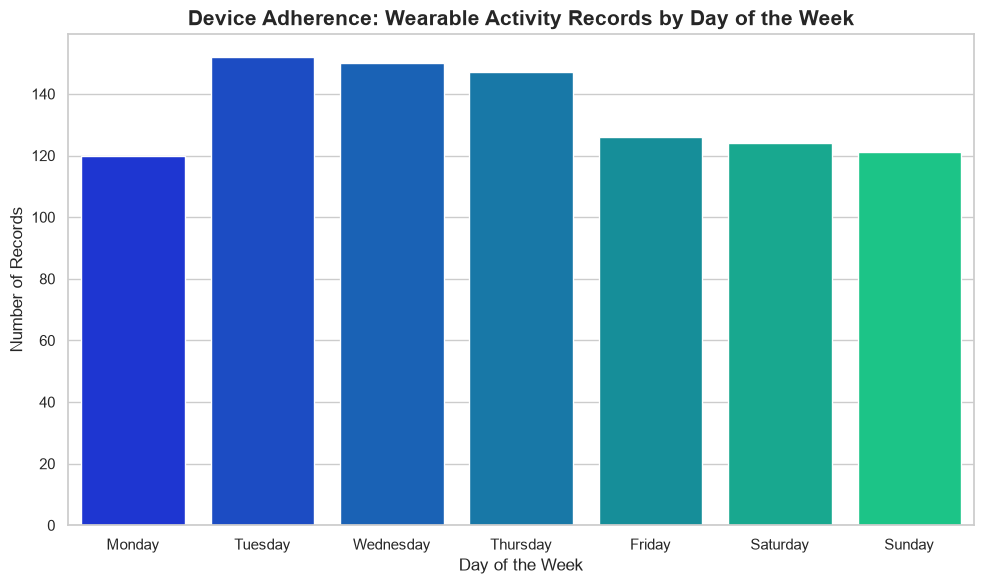

           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366   2016-04-12       13162           8.50             8.50   
1  1503960366   2016-04-13       10735           6.97             6.97   
2  1503960366   2016-04-14       10460           6.74             6.74   
3  1503960366   2016-04-15        9762           6.28             6.28   
4  1503960366   2016-04-16       12669           8.16             8.16   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.44                      0.40   
3                       0.0                2.14                      1.26   
4                       0.0                2.71                      0.41   

   LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  \
0                 6.06

In [ ]:
# 2. Convert ActivityDate to datetime and extract the day name
df_dayActivity['ActivityDate'] = pd.to_datetime(df_dayActivity['ActivityDate'])
df_dayActivity['DayOfWeek'] = df_dayActivity['ActivityDate'].dt.day_name()

# 3. Set the logical order for the week
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 4. Create the count plot
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')
sns.countplot(data=df_dayActivity, x='DayOfWeek', order=week_order, palette='winter')

# 5. English Titles and Labels
plt.title('Device Adherence: Wearable Activity Records by Day of the Week', fontsize=15, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

# print (df_dayActivity.head())
# print ()
# print (df_dayActivity.info())
# print ()
# print (df_dayActivity.describe())
# print ()
# print (df_dayActivity.shape)


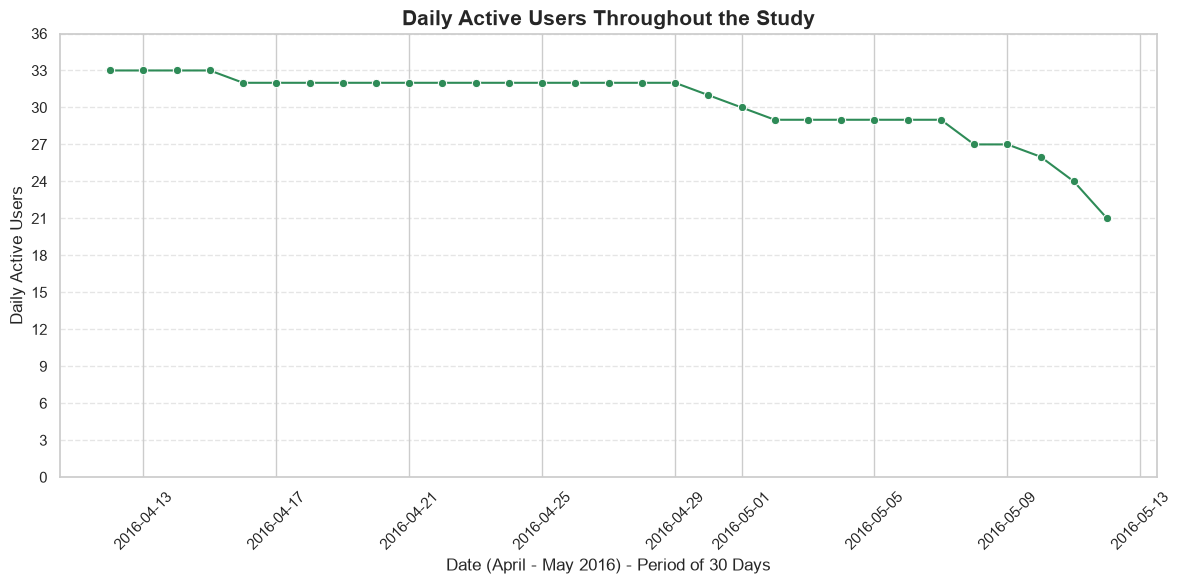

In [51]:
# 1. Use a copy to keep the original data intact
df_timeline = df_dayActivity.copy()
df_timeline['ActivityDate'] = pd.to_datetime(
    df_timeline['ActivityDate']
)

# 2. Group by date and count unique active users
daily_counts = (
    df_timeline
    .groupby('ActivityDate')['Id']
    .nunique()
    .reset_index(name='ActiveUsers')
)

# 3. Create the line plot to show the trend over time
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=daily_counts,
    x='ActivityDate',
    y='ActiveUsers',
    marker='o',
    color='#2E8B57'
)

# 4. Format the Y-axis and horizontal grid
max_active_users = daily_counts['ActiveUsers'].max()

plt.yticks(
    np.arange(0, max_active_users + 4, 3)
)

plt.ylim(0)
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

# 5. Add titles and labels
plt.title(
    'Daily Active Users Throughout the Study',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    'Date (April - May 2016) - Period of 30 Days',
    fontsize=12
)

plt.ylabel(
    'Daily Active Users',
    fontsize=12
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Daily Active Users by Day of Week
-------------------------------------------------------
   DayOfWeek   Mean  Median  StdDev  Min  Max
1     Monday  30.00    30.5    2.45   27   32
5    Tuesday  30.40    32.0    2.88   26   33
6  Wednesday  30.00    32.0    3.67   24   33
4   Thursday  29.40    32.0    4.93   21   33
0     Friday  31.50    32.0    1.73   29   33
2   Saturday  31.00    31.5    1.41   29   32
3     Sunday  30.25    31.0    2.36   27   32

Overall Mean: 30.36


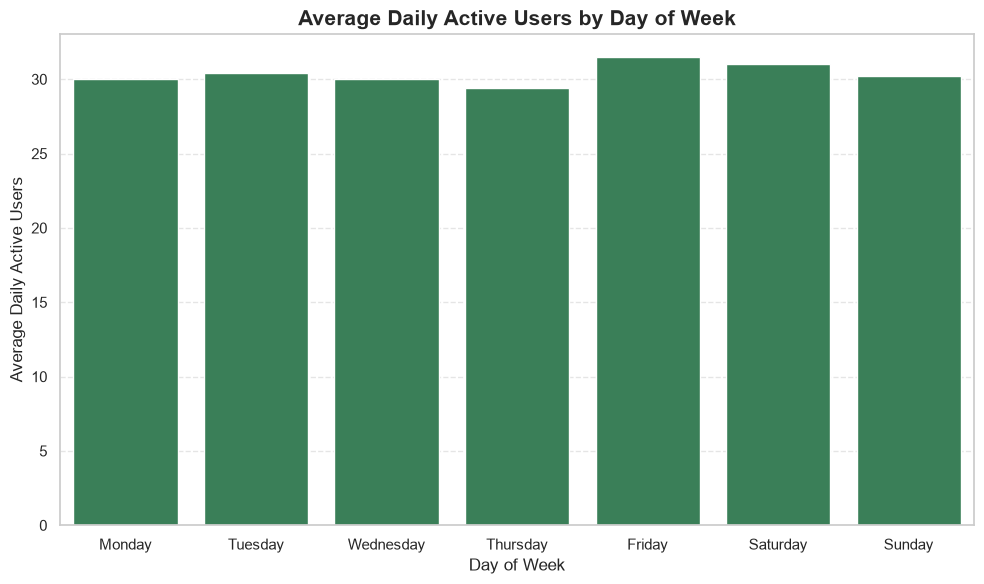

In [58]:
# =============================================================================
# Average Daily Active Users by Day of Week
# Statistical Summary
# =============================================================================

# 1. Create a copy to preserve the original dataset
df_weekday = df_dayActivity.copy()

# 2. Convert ActivityDate to datetime and extract the weekday name
df_weekday['ActivityDate'] = pd.to_datetime(df_weekday['ActivityDate'])

df_weekday['DayOfWeek'] = (
    df_weekday['ActivityDate']
    .dt.day_name()
)

# 3. Define the logical order of the week
week_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

# 4. Count the number of unique active users for each date
daily_active_users = (
    df_weekday
    .groupby('ActivityDate')['Id']
    .nunique()
    .reset_index(name='ActiveUsers')
)

# 5. Extract the weekday again from the summarized table
daily_active_users['DayOfWeek'] = (
    daily_active_users['ActivityDate']
    .dt.day_name()
)

# 6. Calculate descriptive statistics by weekday
weekday_summary = (
    daily_active_users
    .groupby('DayOfWeek')['ActiveUsers']
    .agg(
        Mean='mean',
        Median='median',
        StdDev='std',
        Min='min',
        Max='max'
    )
    .reset_index()
)

# 7. Apply the correct weekday order
weekday_summary['DayOfWeek'] = pd.Categorical(
    weekday_summary['DayOfWeek'],
    categories=week_order,
    ordered=True
)

weekday_summary = (
    weekday_summary
    .sort_values('DayOfWeek')
)

# 8. Round values for readability
weekday_summary = weekday_summary.round(2)

# 9. Display the statistical summary
print("Average Daily Active Users by Day of Week")
print("-" * 55)
print(weekday_summary)
print()
overall_mean = weekday_summary['Mean'].mean()
print(f"Overall Mean: {overall_mean:.2f}")

# 10. Create the bar chart using the Mean
plt.figure(figsize=(10,6))

sns.barplot(
    data=weekday_summary,
    x='DayOfWeek',
    y='Mean',
    color='#2E8B57'
)

# 11. Titles and labels
plt.title(
    'Average Daily Active Users by Day of Week',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    'Day of Week',
    fontsize=12
)

plt.ylabel(
    'Average Daily Active Users',
    fontsize=12
)

# 12. Improve readability
plt.ylim(0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

In [57]:
# Exportar el DataFrame a un archivo CSV
daily_active_users.to_csv('01_daily_active_users.csv', index=False, encoding='utf-8')
weekday_summary.to_csv('02_weekday_summary.csv', index=False, encoding='utf-8')

In [5]:
# 1. Identificar el último y penúltimo día automáticamente
last_day = df_dayActivity['ActivityDate'].max()
day_before = last_day - pd.Timedelta(days=1)

# 2. Lista Persevering: IDs activos en los últimos 2 días
persevering_ids = df_dayActivity[df_dayActivity['ActivityDate'] >= day_before]['Id'].unique().tolist()

# 3. Lista Abandoned: IDs que no están en la lista anterior
all_ids = df_dayActivity['Id'].unique().tolist()
abandoned_ids = [uid for uid in all_ids if uid not in persevering_ids]

# Imprimir resultados de ambos grupos
print(f"Persevering Group ({len(persevering_ids)}):", persevering_ids)
print(f"Abandoned Group ({len(abandoned_ids)}):", abandoned_ids)



Persevering Group (24): [1503960366, 1624580081, 1644430081, 1844505072, 1927972279, 2022484408, 2026352035, 2320127002, 2873212765, 3977333714, 4020332650, 4319703577, 4388161847, 4445114986, 4558609924, 4702921684, 5553957443, 5577150313, 6962181067, 7086361926, 8053475328, 8378563200, 8583815059, 8877689391]
Abandoned Group (9): [2347167796, 3372868164, 4057192912, 6117666160, 6290855005, 6775888955, 7007744171, 8253242879, 8792009665]


C:\Users\andre\AppData\Local\Temp\ipykernel_31820\2225517423.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=abandoned_med, x='ActivityType', y='MedianMinutes', palette='Reds_r', ax=ax1)
C:\Users\andre\AppData\Local\Temp\ipykernel_31820\2225517423.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=persevering_med, x='ActivityType', y='MedianMinutes', palette='Greens_r', ax=ax2)


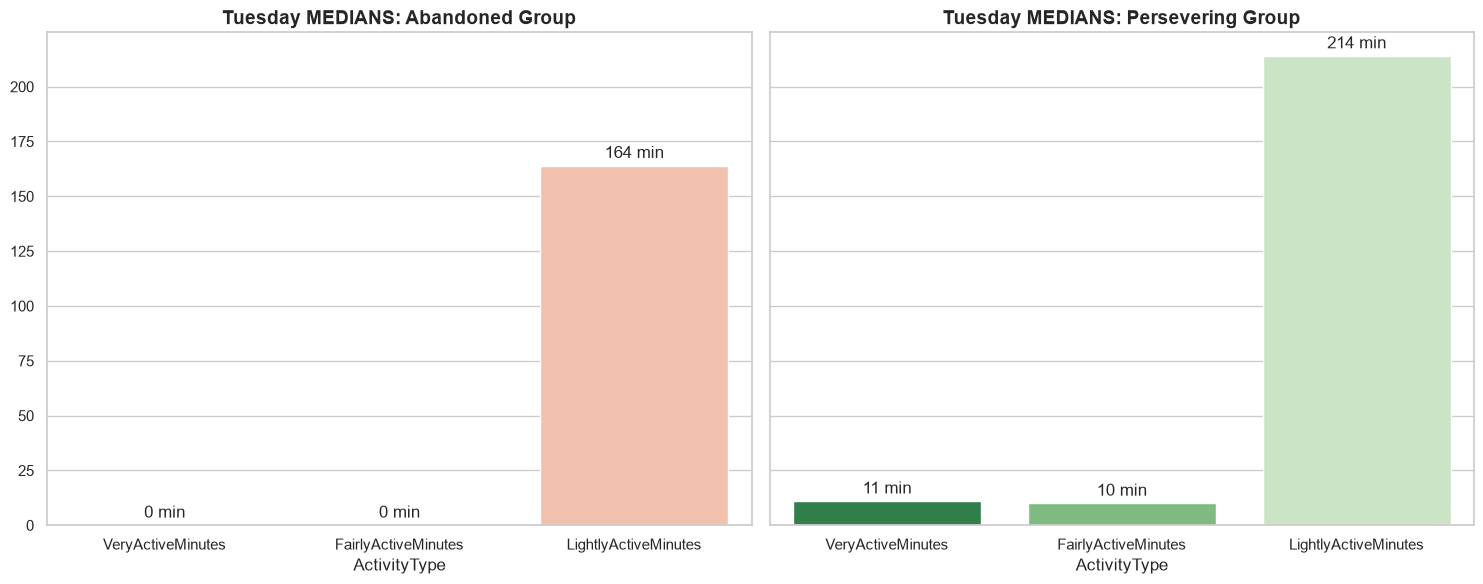

In [42]:
# 1. Crear la copia de seguridad para este análisis específico
df_viz_martes = df_dayActivity.copy()

# 2. Clasificar los grupos en la nueva copia
df_viz_martes['Status'] = df_viz_martes['Id'].apply(
    lambda x: 'Persevering Group' if x in persevering_ids else 'Abandoned Group'
)
# print (df_viz_martes.head())
# print ()
# print (df_viz_martes.info())
# print ()
# print (df_viz_martes.describe())
# print ()
# print (df_viz_martes.shape)

# 3. Filtrar solo los datos de los martes
df_tuesday = df_viz_martes[df_viz_martes['DayOfWeek'] == 'Tuesday']
activity_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes']

# print (df_tuesday.head())
# print ()
# print (df_tuesday.info())
# print ()
# print (df_tuesday.describe())
# print ()
# print (df_tuesday.shape)



# Paso 1: Filtrar las filas por una condición (Filtrado horizontal)
df_filtrado = df_tuesday[df_tuesday['Status'] == 'Abandoned Group']

# Paso 2: Seleccionar solo las columnas de interés (Filtrado vertical)
df_columnas_interes = df_filtrado[activity_cols]

# Paso 3: Calcular la mediana de esas columnas
serie_medianas = df_columnas_interes.median()

# Paso 4: Resetear el índice para convertir el resultado en un DataFrame limpio
abandoned_med = serie_medianas.reset_index()
abandoned_med.columns = ['ActivityType', 'MedianMinutes']


# 4. Crear los dos diagramas (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
ax1, ax2 = axes

sns.barplot(data=abandoned_med, x='ActivityType', y='MedianMinutes', palette='Reds_r', ax=ax1)
ax1.set_title('Tuesday MEDIANS: Abandoned Group', fontsize=14, fontweight='bold')
ax1.set_ylabel('')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f min', padding=3)
    
# # Diagrama 1: Abandoned Group (MEDIANA)
# abandoned_med = df_tuesday[df_tuesday['Status'] == 'Abandoned Group'][activity_cols].median().reset_index()

# # Imprimir el DataFrame justo ANTES de renombrar las columnas (para ver cómo viene por defecto)
# print("--- DataFrame ANTES de renombrar las columnas ---")
# print(abandoned_med)
# print("\n" + "="*40 + "\n")
# print()

# # 2. Renombrar las columnas
# abandoned_med.columns = ['ActivityType', 'MedianMinutes']

# # Imprimir el DataFrame DESPUÉS de renombrar las columnas
# print("--- DataFrame DESPUÉS de renombrar (abandoned_med) ---")
# print(abandoned_med)
# print("\n" + "="*40 + "\n")
# print()

# # Imprimir específicamente los nombres de las columnas (abandoned_med.columns)
# print("--- Nombres de las columnas (abandoned_med.columns) ---")
# print(abandoned_med.columns)



# Diagrama 2: Persevering Group (MEDIANA)
persevering_med = df_tuesday[df_tuesday['Status'] == 'Persevering Group'][activity_cols].median().reset_index()
persevering_med.columns = ['ActivityType', 'MedianMinutes']
sns.barplot(data=persevering_med, x='ActivityType', y='MedianMinutes', palette='Greens_r', ax=ax2)
ax2.set_title('Tuesday MEDIANS: Persevering Group', fontsize=14, fontweight='bold')
ax2.set_ylabel('Median Minutes')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.0f min', padding=3)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_31820\2108396620.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=abandoned_med, x='ActivityType', y='MedianMinutes', palette='Reds_r', ax=ax1)
C:\Users\andre\AppData\Local\Temp\ipykernel_31820\2108396620.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=persevering_med, x='ActivityType', y='MedianMinutes', palette='Greens_r', ax=ax2)


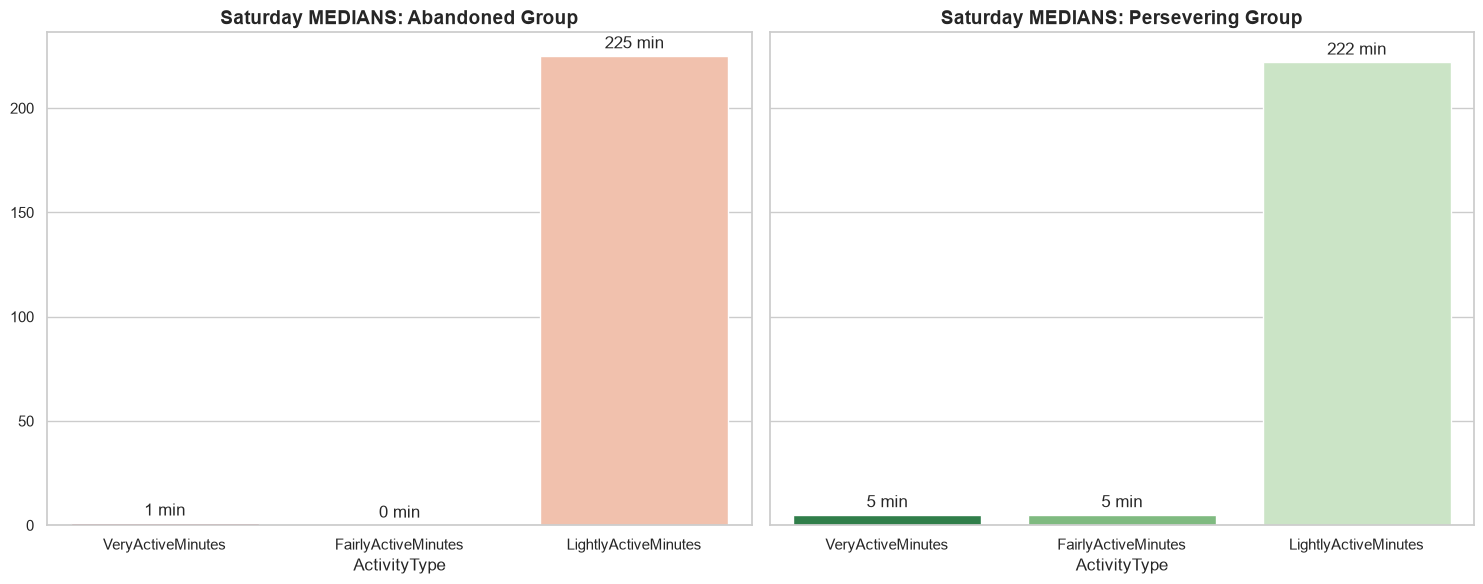

In [23]:
# 1. Crear la copia de seguridad para este análisis específico
df_viz_saturday = df_dayActivity.copy()

# 2. Clasificar los grupos en la nueva copia
df_viz_saturday['Status'] = df_viz_saturday['Id'].apply(
    lambda x: 'Persevering Group' if x in persevering_ids else 'Abandoned Group'
)

# 3. Filtrar solo los datos de los martes
df_tuesday = df_viz_saturday[df_viz_saturday['DayOfWeek'] == 'Saturday']
activity_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes']

# 4. Crear los dos diagramas (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
ax1, ax2 = axes



# Diagrama 1: Abandoned Group (MEDIANA)
abandoned_med = df_tuesday[df_tuesday['Status'] == 'Abandoned Group'][activity_cols].median().reset_index()
abandoned_med.columns = ['ActivityType', 'MedianMinutes']
sns.barplot(data=abandoned_med, x='ActivityType', y='MedianMinutes', palette='Reds_r', ax=ax1)
ax1.set_title('Saturday MEDIANS: Abandoned Group', fontsize=14, fontweight='bold')
ax1.set_ylabel('')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f min', padding=3)


# Diagrama 2: Persevering Group (MEDIANA)
persevering_med = df_tuesday[df_tuesday['Status'] == 'Persevering Group'][activity_cols].median().reset_index()
persevering_med.columns = ['ActivityType', 'MedianMinutes']
sns.barplot(data=persevering_med, x='ActivityType', y='MedianMinutes', palette='Greens_r', ax=ax2)
ax2.set_title('Saturday MEDIANS: Persevering Group', fontsize=14, fontweight='bold')
ax2.set_ylabel('Median Minutes')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.0f min', padding=3)


plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_31820\2214822457.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=abandoned_cal, x='DayOfWeek', y='Calories', palette='Reds_r', ax=ax1)
C:\Users\andre\AppData\Local\Temp\ipykernel_31820\2214822457.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=persevering_cal, x='DayOfWeek', y='Calories', palette='Greens_r', ax=ax2)


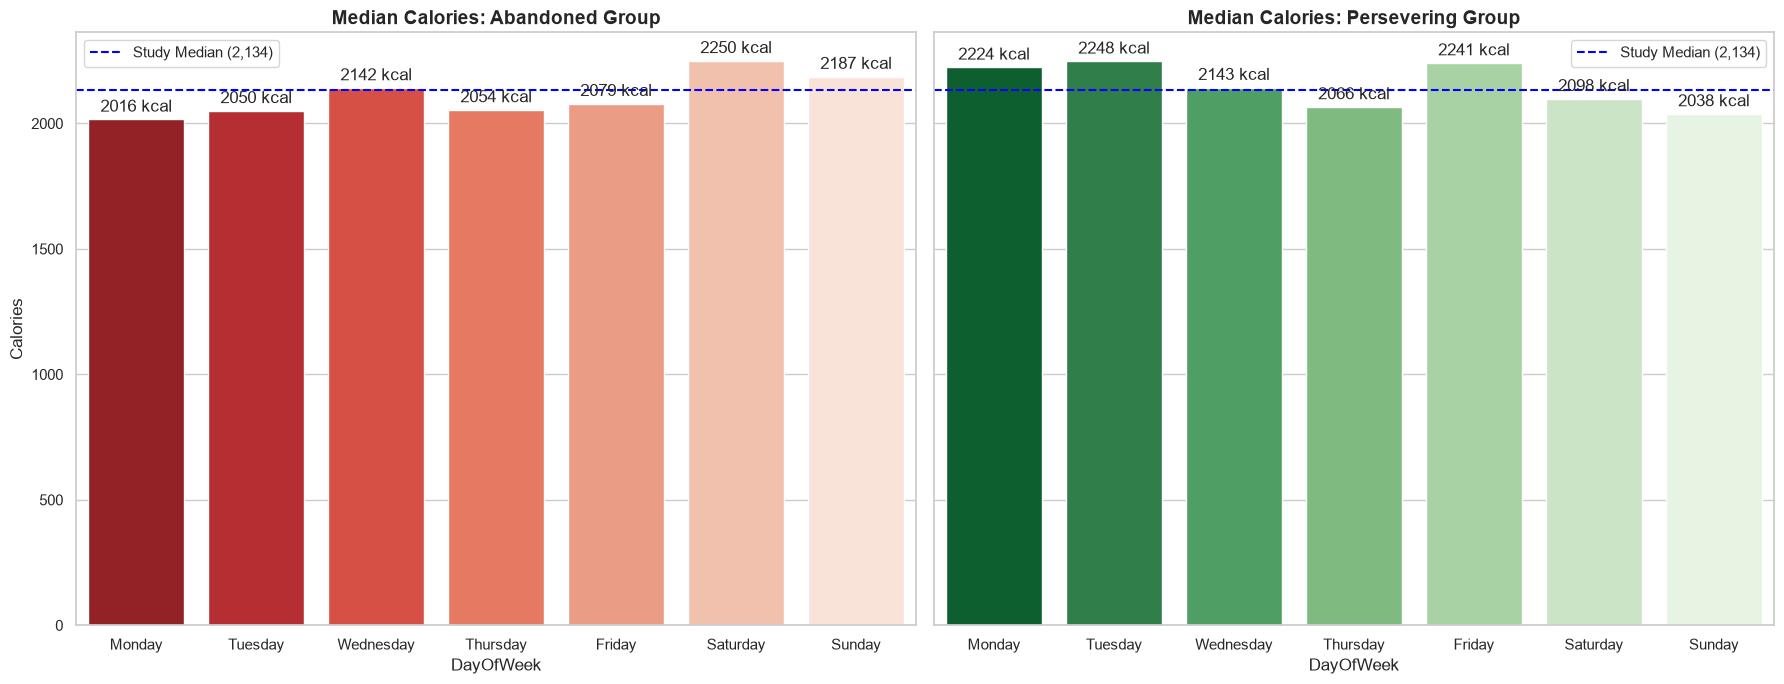

In [29]:
# 1. Crear copia de seguridad
df_cal_groups = df_dayActivity.copy()

# 2. Clasificar grupos y definir orden de días
df_cal_groups['Status'] = df_cal_groups['Id'].apply(
    lambda x: 'Abandoned Group' if x in abandoned_ids else 'Persevering Group'
)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 3. Crear la figura (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
ax1, ax2 = axes

# Diagrama 1: Abandoned Group (Izquierda)
abandoned_cal = df_cal_groups[df_cal_groups['Status'] == 'Abandoned Group'].groupby('DayOfWeek')['Calories'].median().reindex(day_order).reset_index()
sns.barplot(data=abandoned_cal, x='DayOfWeek', y='Calories', palette='Reds_r', ax=ax1)
ax1.set_title('Median Calories: Abandoned Group', fontsize=14, fontweight='bold')
for container in ax1.containers:
	ax1.bar_label(container, fmt='%.0f kcal', padding=3)

# Diagrama 2: Persevering Group (Derecha)
persevering_cal = df_cal_groups[df_cal_groups['Status'] == 'Persevering Group'].groupby('DayOfWeek')['Calories'].median().reindex(day_order).reset_index()
sns.barplot(data=persevering_cal, x='DayOfWeek', y='Calories', palette='Greens_r', ax=ax2)
ax2.set_title('Median Calories: Persevering Group', fontsize=14, fontweight='bold')
for container in ax2.containers:
	ax2.bar_label(container, fmt='%.0f kcal', padding=3)

# Línea de referencia del Median general (2,304 kcal)
for ax in axes:
    ax.axhline(2134, color='blue', linestyle='--', label='Study Median (2,134)')
    ax.legend()

plt.tight_layout()
plt.show()
